# 📈 Zeitreihenprognose mit Prophet
## Hands-On Crashkurs

---

In dieser Session lernen wir, wie Prophet unter der Haube funktioniert. Statt mit echten, unaufgeräumten Daten zu arbeiten, generieren wir uns direkt einen **fertigen, synthetischen Umsatz-Datensatz** (in USD) für ein fiktives E-Commerce-Produkt (SkyDrive X1 Pro SSD).

Da wir die Struktur der Daten selbst definieren, können wir am Ende exakt überprüfen, ob Prophet die eingebauten Muster korrekt identifiziert.

### 🧮 Die mathematische Basis (Die Prophet-Gleichung)
Prophet modelliert Zeitreihen als additives Modell, das sich aus drei Hauptkomponenten und einem Fehlerterm zusammensetzt:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

- **$g(t)$:** Trend (langfristige Veränderungen wie Wachstum/Rückgang)
- **$s(t)$:** Saisonalität (periodische Veränderungen, z. B. wöchentlich oder jährlich)
- **$h(t)$:** Holidays / Events (Ausreißer durch Feiertage oder besondere Ereignisse)
- **$\epsilon_t$:** Fehlerterm (zufälliges Rauschen)

Wir werden in diesem Beispiel besonders den Effekt des **Holiday Features ($h(t)$)** kennenlernen und herausfinden, warum Domänenwissen bei Ausreißern unverzichtbar ist. 

**Unser synthetischer Umsatz-Datensatz enthält exakt diese Bausteine:**
- 📈 Einen stetigen **Aufwärtstrend** (Umsatzwachstum über die Jahre)
- 📅 **Jährliche Saisonalität:** Höhere Umsätze im Sommer
- 📆 **Wöchentliche Saisonalität:** Umsatzspitzen an den Wochenenden
- 🛍️ **Black Friday:** Ein starker Ausreißer jeden November

Das Notebook ist dreigeteilt. Im ersten Teil wird der Datensatz gemeinsam erzeugt. Im zweiten soll PROPHET zunächst ohne das holidays feature ausprobiert werden. Im dritten Teil schließlich in der analyst-in-the-loop Variante mit dem Expertenwissen zum Black Friday.

---
## 📊 Unser Datensatz – SkyDrive X1 Pro externe SSD

Wir simulieren den **täglichen Umsatz** einer externen SSD – der *SkyDrive X1 Pro* –
über 4 Jahre (2020–2023). Das Produkt profitiert jedes Jahr stark vom **Black Friday**
und den umliegenden Tagen.

**Preisstruktur:**

| Zeitraum | Verkaufspreis | Rabatt | Mengen-Effekt |
|---|---|---|---|
| Normaltage | 129.00 USD | – | Basismenge (Trend + Saisonalität) |
| 3 Tage vor Black Friday | 104.49 USD | −19 % | +120 Einheiten/Tag (Vorverkauf) |
| Black Friday | 78.69 USD | −39 % | +500 Einheiten (Haupt-Event) |
| Tag nach BF (Samstag) | 78.69 USD | −39 % | +250 Einheiten (Angebote laufen weiter) |

So sehen die Umsatzdaten aus – die wir im Folgenden synthetisch nachbauen:

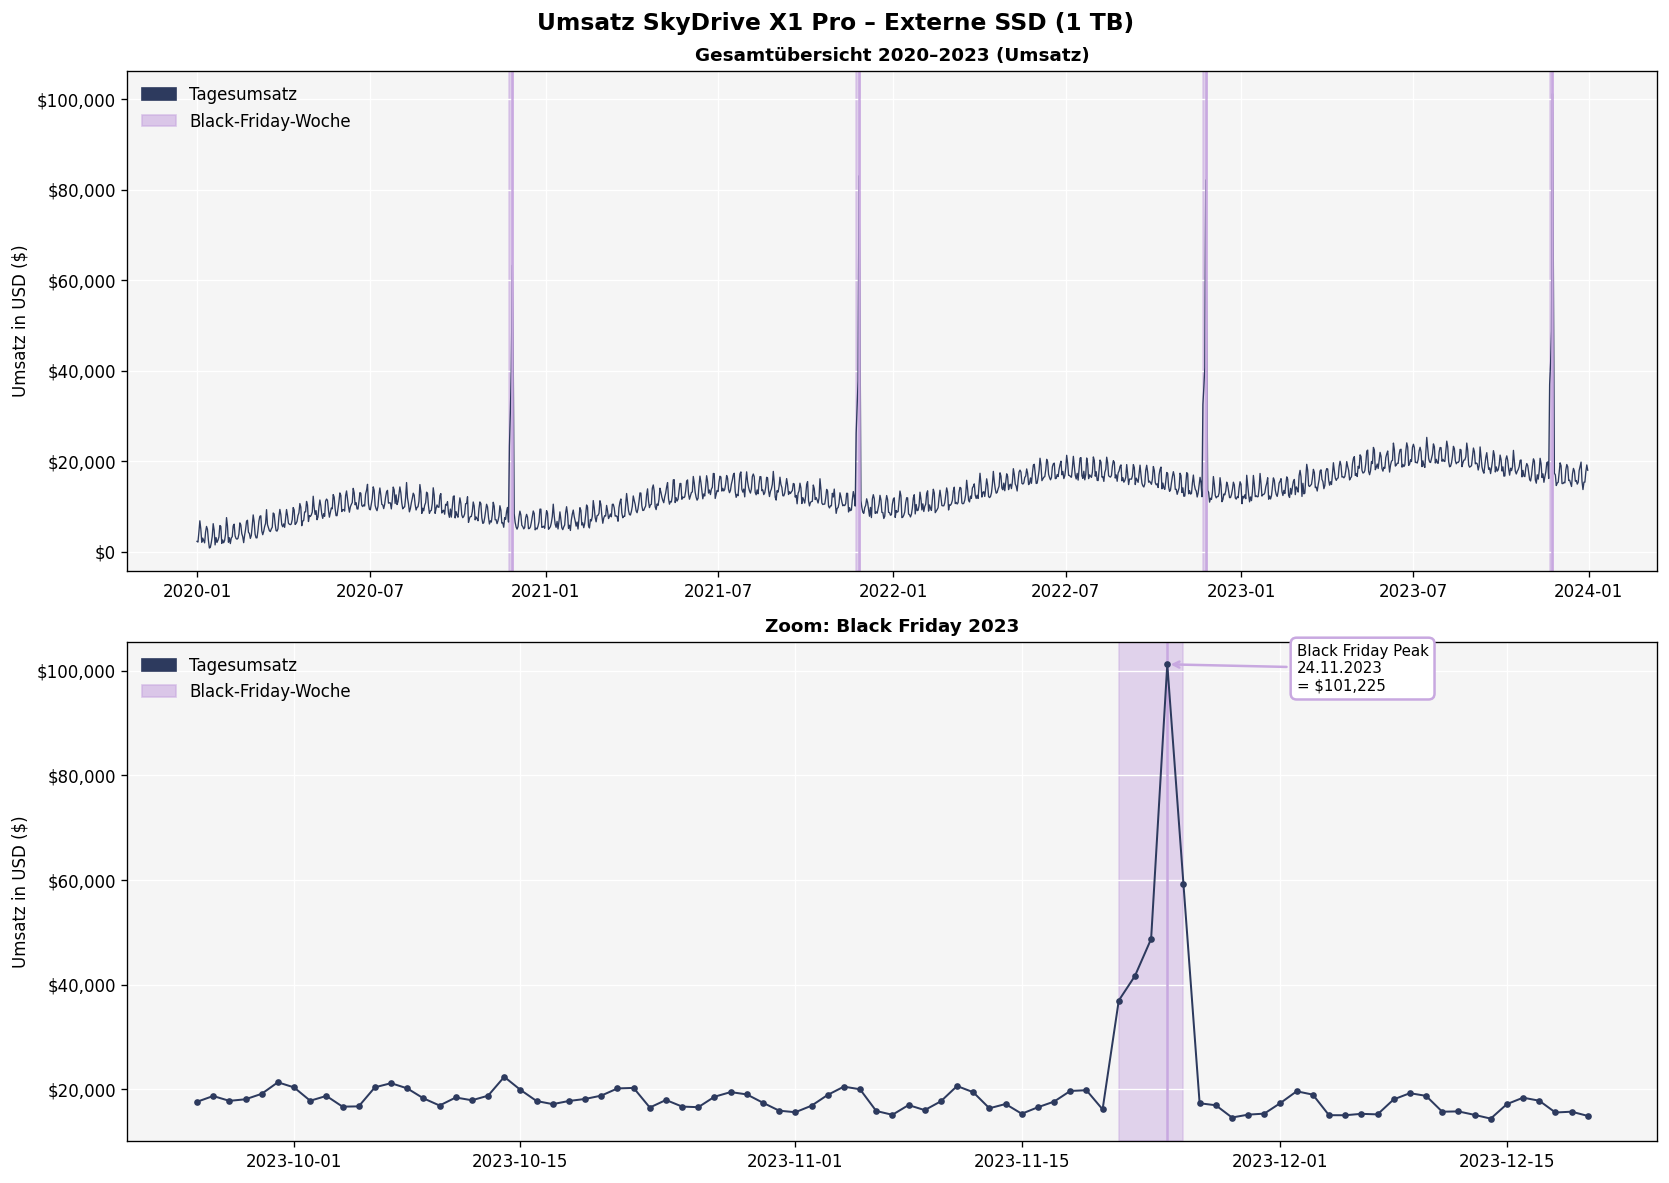

---
## 🔧 Teil A: Setup & Datengenerierung (vorgegeben)

Dieser Teil ist bereits fertig – führe die Zellen einfach aus.

In [1]:
# --- DATENGENERIERUNG (Komplett vorgegeben) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2023-12-31')
df = pd.DataFrame({'ds': dates})  # Prophet erwartet die Datumsspalte immer als 'ds'

# ── 1. Basis-Umsatzbausteine (direkt in USD $) ───────────────────────────────
# Trend: linearer Umsatzanstieg von ~6.450 $ auf 19.350 $ pro Tag
df['trend'] = np.linspace(6450, 19350, len(dates))

# Rauschen: unvorhersehbare Schwankungen (σ = 650 $)
df['noise'] = np.random.normal(0, 650, len(dates))

# Wöchentliche Saisonalität (Umsatz-Abweichung vom Tagesmittel in $)
df['weekly'] = df['ds'].dt.dayofweek.map({
    0: -1030, 1: -1290, 2: -1290, 3: -1030, 4: 650, 5: 2580, 6: 1935
})

# Jährliche Saisonalität: Amplitude ±3.225 $ (Sommer vs. Winter)
df['yearly'] = 3225 * np.sin(2 * np.pi * (df['ds'].dt.dayofyear - 100) / 365.25)

### 🛍️ Was ist der Black Friday – und auf welchen Tag fällt er?

Der Black Friday findet traditionell immer am Tag **nach dem amerikanischen Feiertag Thanksgiving** statt.
Da Thanksgiving in den USA immer auf den **vierten Donnerstag im November** fällt, ist der Black Friday ebenfalls ein "bewegliches Event" folglich immer der **vierte Freitag im November**.

| Jahr | Black Friday |
|---|---|
| 2020 | 27. November |
| 2021 | 26. November |
| 2022 | 25. November |
| 2023 | 24. November |
| 2026 | 27. November |
| 2027 | 26. November |
| 2028 | 24. November |

Diese Regel lässt sich programmatisch berechnen – wir müssen die Daten also **nicht** hart kodieren,
sondern können sie automatisch für beliebige Jahre ableiten.

In [2]:
# ── 2. Black Friday Umsatz-Effekt ($) ────────────────────────────────────────
def black_friday(year):
    return pd.date_range(f'{year}-11-01', f'{year}-11-30', freq='W-FRI')[3]

black_fridays = pd.to_datetime([black_friday(y) for y in [2020, 2021, 2022, 2023]])

rng = np.random.default_rng(seed=42)

df['bf_effect'] = 0.0
for bf in black_fridays:
    year_factor = np.clip(rng.normal(1.0, 0.2), 0.6, 1.4)

    for offset, extra_umsatz in [(-3, 18000), (-2, 22000), (-1, 30000), (0, 65000), (1, 35000)]:
        day_noise = rng.normal(0, extra_umsatz * 0.10)  # 10% tägliches Rauschen
        scaled = extra_umsatz * year_factor + day_noise
        df.loc[df['ds'] == bf + pd.Timedelta(days=offset), 'bf_effect'] = max(0, scaled)

# ── 3. Finale Zielvariable (y) berechnen ─────────────────────────────────────
# Prophet lernt auf der Spalte 'y'. Da wir ein additives Modell simulieren, 
# addieren wir einfach alle Bausteine zum täglichen Gesamtumsatz:
df['y'] = df['trend'] + df['noise'] + df['weekly'] + df['yearly'] + df['bf_effect']

# ── 4. Ausgaben zur Kontrolle ────────────────────────────────────────────────
print('✅ Synthetischer Umsatz-Datensatz erfolgreich generiert!')
print(f'   {len(df)} Tage vom {df["ds"].min().date()} bis {df["ds"].max().date()}')
print()
print('Eingebaute Muster im Überblick (Alles in USD):')
print(f'  Trend:        Wächst von 6.450 $ auf 19.350 $ pro Tag')
print(f'  Woche:        Samstag +2.580 $ / Dienstag -1.290 $')
print(f'  Jahr:         Amplitude ±3.225 $ (Sommer vs. Winter)')
print(f'  Black Friday: Bis zu +65.000 $ Extra-Umsatz am Peak-Tag')

✅ Synthetischer Umsatz-Datensatz erfolgreich generiert!
   1461 Tage vom 2020-01-01 bis 2023-12-31

Eingebaute Muster im Überblick (Alles in USD):
  Trend:        Wächst von 6.450 $ auf 19.350 $ pro Tag
  Woche:        Samstag +2.580 $ / Dienstag -1.290 $
  Jahr:         Amplitude ±3.225 $ (Sommer vs. Winter)
  Black Friday: Bis zu +65.000 $ Extra-Umsatz am Peak-Tag


### 📊 Datensatz visualisieren (automatisch – einfach ausführen)

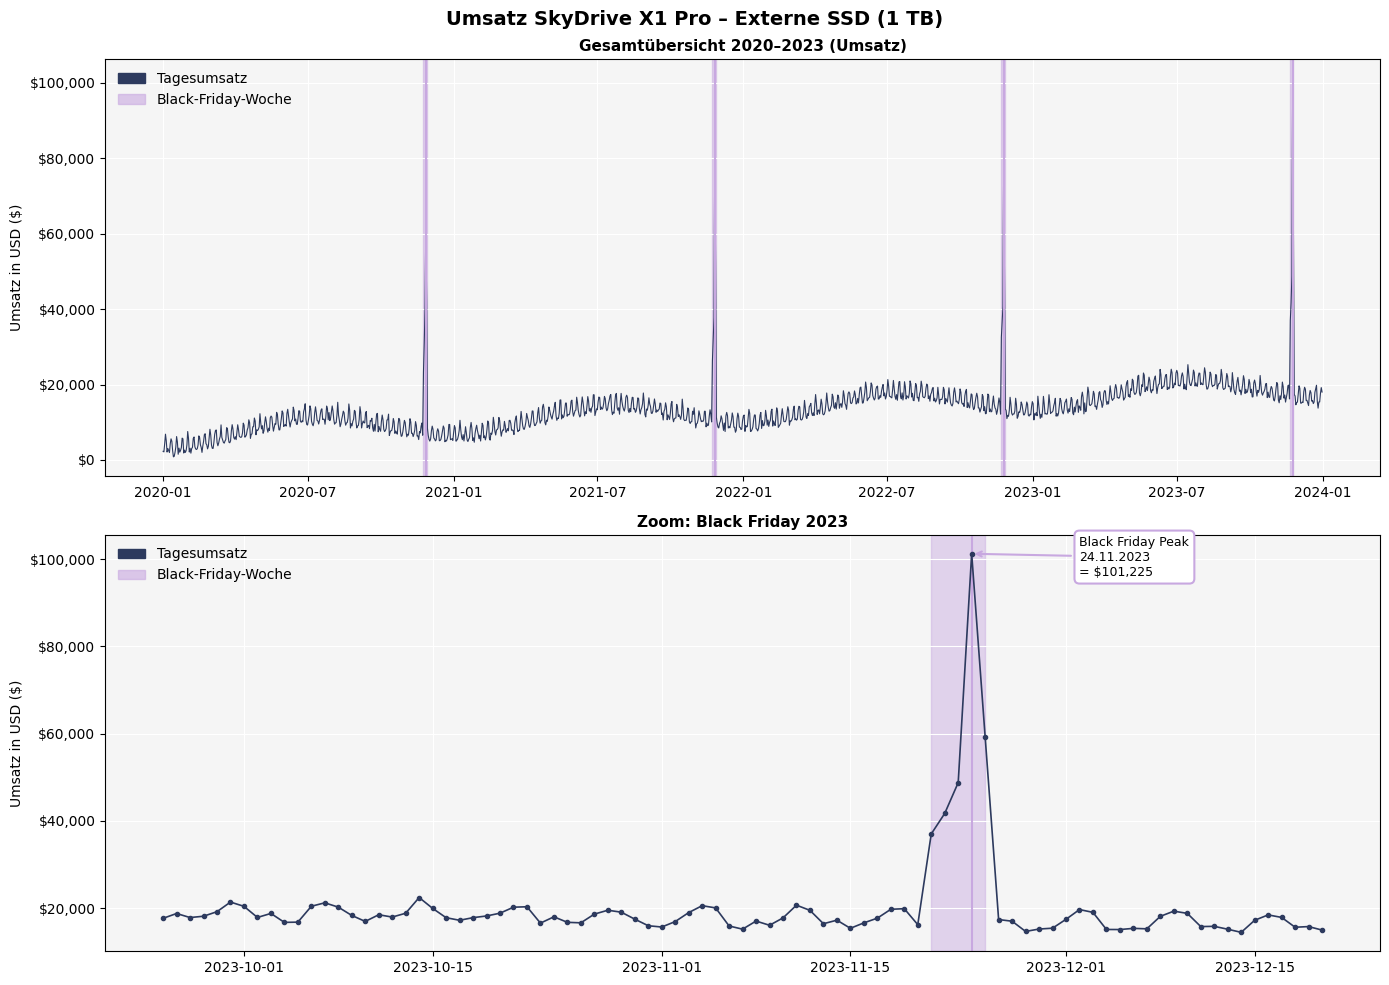

In [3]:
# ------------------------------------------------------------
# AUTO-PLOT: Umsatz SkyDrive X1 Pro – einfach ausführen!
# ------------------------------------------------------------

BF_COLOR   = '#c8a8e0'
LINE_COLOR = '#2d3a5e'

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Umsatz SkyDrive X1 Pro – Externe SSD (1 TB)', fontsize=14, fontweight='bold', y=0.98)

# ── Subplot 1: Gesamtübersicht 2020–2023 ──────────────────────────────────────
ax1 = axes[0]
ax1.set_title('Gesamtübersicht 2020–2023 (Umsatz)', fontsize=11, fontweight='bold')
ax1.plot(df['ds'], df['y'], color=LINE_COLOR, linewidth=0.8)

for bf in black_fridays:
    ax1.axvspan(bf + pd.Timedelta(days=-3), bf + pd.Timedelta(days=1),
                color=BF_COLOR, alpha=0.5)
    ax1.axvline(bf, color=BF_COLOR, linewidth=1.5)

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylabel('Umsatz in USD ($)')
ax1.set_facecolor('#f5f5f5')
ax1.grid(True, color='white', linewidth=0.8)
ax1.legend(handles=[
    mpatches.Patch(color=LINE_COLOR, label='Tagesumsatz'),
    mpatches.Patch(color=BF_COLOR,   label='Black-Friday-Woche', alpha=0.6),
], loc='upper left', frameon=False)

# ── Subplot 2: Zoom Black Friday 2023 ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('Zoom: Black Friday 2023', fontsize=11, fontweight='bold')

df_zoom = df[(df['ds'] >= '2023-09-25') & (df['ds'] <= '2023-12-20')]
bf_2023 = black_fridays[-1]

ax2.axvspan(bf_2023 + pd.Timedelta(days=-3), bf_2023 + pd.Timedelta(days=1),
            color=BF_COLOR, alpha=0.45)
ax2.axvline(bf_2023, color=BF_COLOR, linewidth=1.5)
ax2.plot(df_zoom['ds'], df_zoom['y'], color=LINE_COLOR,
         linewidth=1.2, marker='o', markersize=3)

ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylabel('Umsatz in USD ($)')
ax2.set_facecolor('#f5f5f5')
ax2.grid(True, color='white', linewidth=0.8)

peak = df_zoom.loc[df_zoom['y'].idxmax()]
ax2.annotate(
    f'Black Friday Peak\n{peak["ds"].strftime("%d.%m.%Y")}\n= ${peak["y"]:,.0f}',
    xy=(peak['ds'], peak['y']),
    xytext=(peak['ds'] + pd.Timedelta(days=8), peak['y'] - 5000),
    arrowprops=dict(arrowstyle='->', color=BF_COLOR, lw=1.5),
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=BF_COLOR, linewidth=1.5)
)
ax2.legend(handles=[
    mpatches.Patch(color=LINE_COLOR, label='Tagesumsatz'),
    mpatches.Patch(color=BF_COLOR,   label='Black-Friday-Woche', alpha=0.6),
], loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

---
## ✏️ Teil B: Aufgabe 1 – Prophet ohne Feiertage trainieren

Wir teilen den Datensatz in Training und Test auf:
- **Training (2020–2022):** Prophet lernt Trend und Saisonalität aus drei Jahren
- **Test (2023):** Wir prüfen, ob das Modell den Black Friday 2023 korrekt vorhersagt

```
─────────────────────────────────┬──────────────
        Training (2020–2022)     │  Test (2023)
─────────────────────────────────┴──────────────
                          01.01.2023
```

**Prophet API:**
```python
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(df_train[['ds', 'y']])          # Training
forecast = m.predict(df_test[['ds']]) # Vorhersage für Testzeitraum
# Ergebnis enthält: ds, yhat (Vorhersage), yhat_lower, yhat_upper
```

> 💡 **Hinweis:** Die Plot-Zelle darunter läuft automatisch – sie braucht aber die Variablen
> `df_train`, `df_test` und `forecast_naive` aus dieser Zelle. Achte auf die korrekten Namen!

In [4]:
# ============================================================
# ✏️  AUFGABE 1 – Hier müsst ihr programmieren!
# ============================================================

from prophet import Prophet

print('Trainiere das Naive Modell (ignoriert Black Friday)...')

# ── Schritt 1: Train/Test-Split ───────────────────────────────────────────────
# ✏️ TODO: Setzt das Split-Datum auf den 1. Januar 2023
SPLIT_DATE = '???'  # <-- hier ergänzen

df_train = df[df['ds'] < SPLIT_DATE]
df_test  = df[df['ds'] >= SPLIT_DATE]

print(f'Training: {df_train["ds"].min().date()} bis {df_train["ds"].max().date()} ({len(df_train)} Tage)')
print(f'Test:     {df_test["ds"].min().date()} bis {df_test["ds"].max().date()} ({len(df_test)} Tage)')

# ── Schritt 2: Modell initialisieren ─────────────────────────────────────────
# ✏️ TODO: Prophet-Modell erstellen (yearly + weekly Saisonalität, KEINE daily)
m_naive = ???  # <-- hier ergänzen

# ── Schritt 3: Modell trainieren ──────────────────────────────────────────────
# ✏️ TODO: Modell auf Trainingsdaten fitten (nur Spalten 'ds' und 'y' übergeben!)
???  # <-- hier ergänzen

# ── Schritt 4: Vorhersage erstellen ───────────────────────────────────────────
# ✏️ TODO: Vorhersage für den Testzeitraum (df_test) erstellen
# Ergebnis soll in der Variable 'forecast_naive' gespeichert werden!
forecast_naive = ???  # <-- hier ergänzen

print('✅ Naives Modell trainiert!')

SyntaxError: invalid syntax (1201934107.py, line 21)

### 📊 Ergebnis visualisieren (automatisch – einfach ausführen)

In [ ]:
# ------------------------------------------------------------
# AUTO-PLOT: Naives Modell – einfach ausführen!
# ------------------------------------------------------------

ZOOM_START = '2023-10-01'
ZOOM_END   = '2023-12-15'

# --- Plot 1: Gesamtübersicht ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_train['ds'], df_train['y'], color='#666666', linewidth=1,
        label='Training (2020–2022)', alpha=1.0)
ax.plot(df_test['ds'], df_test['y'], color='black', linewidth=1.5,
        label='Echte Verkäufe 2023')
ax.plot(forecast_naive['ds'], forecast_naive['yhat'], color='#e74c3c',
        linewidth=2, linestyle='--', label='Vorhersage (naiv)')
ax.fill_between(forecast_naive['ds'],
                forecast_naive['yhat_lower'], forecast_naive['yhat_upper'],
                alpha=0.15, color='#e74c3c')
ax.axvline(pd.to_datetime(SPLIT_DATE), color='steelblue', linestyle='--',
           linewidth=1.5, label='Train/Test-Split')
ax.axvline(pd.to_datetime('2023-11-24'), color='purple', alpha=0.25,
           linewidth=10, label='Black Friday 2023')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Naives Modell – Gesamtübersicht Testzeitraum 2023', fontweight='bold')
ax.set_ylabel('Umsatz in USD ($)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Plot 2: Zoom auf Black Friday ---
test_zoom     = df_test[(df_test['ds'] >= ZOOM_START) & (df_test['ds'] <= ZOOM_END)]
forecast_zoom = forecast_naive[(forecast_naive['ds'] >= ZOOM_START) & (forecast_naive['ds'] <= ZOOM_END)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_zoom['ds'], test_zoom['y'], marker='o', color='black', markersize=4,
        linewidth=1.5, label='Echte Verkäufe')
ax.plot(forecast_zoom['ds'], forecast_zoom['yhat'], color='#e74c3c',
        linewidth=2, linestyle='--', label='Vorhersage (naiv)')
ax.fill_between(forecast_zoom['ds'],
                forecast_zoom['yhat_lower'], forecast_zoom['yhat_upper'],
                alpha=0.15, color='#e74c3c')
ax.axvline(pd.to_datetime('2023-11-24'), color='purple', alpha=0.25,
           linewidth=10, label='Black Friday (24.11.2023)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Zoom: Naives Modell – Oktober bis Dezember 2023', fontweight='bold')
ax.set_ylabel('Umsatz in USD ($)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('🔍 Was fällt euch auf?')

---
## 🔧 Teil C: Black Friday-Kalender (vorgegeben)

Prophet erwartet Feiertage als DataFrame mit folgenden Spalten:

| Spalte | Bedeutung | Beispiel |
|---|---|---|
| `holiday` | Name des Feiertags | `'Black Friday'` |
| `ds` | Datum(sliste) | `black_fridays` |
| `lower_window` | Tage **vor** dem Feiertag mit Effekt | `-3` = 3 Tage vorher |
| `upper_window` | Tage **nach** dem Feiertag mit Effekt | `1` = noch der Folgetag |

Wir haben in der Datengenerierung angenommen:
- **3 Tage vorher** starten Vorverkaufsangebote
- **1 Tag danach** laufen die Angebote noch weiter

→ `lower_window = -3` und `upper_window = 1`

Führe die Zelle einfach aus – der Kalender ist fertig vorbereitet.

In [ ]:
# --- BLACK FRIDAY KALENDER (Komplett vorgegeben) ---
bf_df = pd.DataFrame({
    'holiday': 'Black Friday',
    'ds': black_fridays,
    'lower_window': -3,  # 3 Tage vorher: Vorverkaufs-Angebote (Di–Do)
    'upper_window': 1,   # 1 Tag danach: Angebote laufen noch am Samstag
})
print('✅ Black Friday Kalender:')
print(bf_df.to_string(index=False))
print()
print('💡 lower_window=-3: Effekt beginnt 3 Tage VOR dem Black Friday (Dienstag)')
print('   upper_window= 1: Effekt dauert 1 Tag danach an (Samstag)')
print()
print('   Prophet lernt damit: Die gesamte Black-Friday-Woche ist besonders –')
print('   nicht nur der Freitag selbst.')

---
## ✏️ Teil D: Aufgabe 2 – Prophet mit Feiertagen trainieren (Experten-Modell)

Jetzt trainieren wir Prophet **mit** dem Black Friday-Kalender (`bf_df`).
Der einzige Unterschied zum naiven Modell: wir übergeben `holidays=bf_df` beim Erstellen des Modells.

```python
m = Prophet(holidays=bf_df, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
```

**Wichtig:** Gleicher Train/Test-Split wie in Teil B – `df_train` und `df_test` sind schon definiert.

> 💡 **Hinweis:** Der Vergleichs-Plot darunter braucht `forecast_naive` (aus Teil B) und `forecast_expert` (aus dieser Zelle).

In [ ]:
# ============================================================
# ✏️  AUFGABE 2 – Hier müsst ihr programmieren!
# ============================================================

print('Trainiere das Experten-Modell (kennt Black Friday)...')

# ── Schritt 1: Modell initialisieren ─────────────────────────────────────────
# ✏️ TODO: Prophet-Modell MIT dem Black Friday-Kalender erstellen
# Hinweis: Prophet(holidays=bf_df, yearly_seasonality=..., ...)
m_expert = ???  # <-- hier ergänzen

# ── Schritt 2: Modell trainieren ──────────────────────────────────────────────
# ✏️ TODO: Modell auf dieselben Trainingsdaten fitten wie in Teil B
???  # <-- hier ergänzen

# ── Schritt 3: Vorhersage erstellen ───────────────────────────────────────────
# ✏️ TODO: Vorhersage für den Testzeitraum erstellen
# Ergebnis soll in der Variable 'forecast_expert' gespeichert werden!
forecast_expert = ???  # <-- hier ergänzen

print('✅ Experten-Modell trainiert!')

### 📊 Showdown: Naives Modell vs. Experten-Modell (automatisch – einfach ausführen)

In [ ]:
# ------------------------------------------------------------
# AUTO-PLOT: Showdown – einfach ausführen!
# ------------------------------------------------------------

ZOOM_START = '2023-10-01'
ZOOM_END   = '2023-12-15'

actual_zoom = df[(df['ds'] >= ZOOM_START) & (df['ds'] <= ZOOM_END)]
naive_zoom  = forecast_naive[(forecast_naive['ds'] >= ZOOM_START) & (forecast_naive['ds'] <= ZOOM_END)]
expert_zoom = forecast_expert[(forecast_expert['ds'] >= ZOOM_START) & (forecast_expert['ds'] <= ZOOM_END)]

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(actual_zoom['ds'], actual_zoom['y'], marker='o', color='black',
        label='Echte Verkäufe', linewidth=2, markersize=4)
ax.plot(naive_zoom['ds'], naive_zoom['yhat'], linestyle='--', color='#e74c3c',
        linewidth=2.5, label='Naives Modell (verpasst den Feiertag)')
ax.plot(expert_zoom['ds'], expert_zoom['yhat'], linestyle='-', color='#2ecc71',
        linewidth=2.5, label='Experten-Modell (kennt den Feiertag)')
ax.axvline(pd.to_datetime('2023-11-24'), color='purple', alpha=0.2,
           linewidth=12, label='Black Friday (24.11.2023)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Black Friday Showdown: Naives vs. Experten-Modell', fontsize=16, fontweight='bold')
ax.set_ylabel('Umsatz in USD ($)', fontsize=12)
ax.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

print('🔍 Beobachtung:')
print('Das rote Modell verpasst nicht nur den Ausreißer, sondern überschätzt')
print('zur Kompensation den Zeitraum davor und danach.')
print('Das grüne Modell trennt das Basisgeschäft sauber vom Feiertags-Effekt.')

---
## 🏆 Zusammenfassung

| | Naives Modell | Experten-Modell |
|---|---|---|
| Black Friday erkannt? | ❌ Nein | ✅ Ja |
| Basisgeschäft korrekt? | ⚠️ Verzerrt | ✅ Sauber |
| Domänenwissen nötig? | ❌ | ✅ Analyst-in-the-Loop |

**Key Takeaway:** Prophet ist ein additives Modell – es zerlegt die Zeitreihe in Trend + Saisonalität + Feiertage. Feiertags-Wissen muss der Analyst explizit einbringen.

### 💬 Diskussionsfragen

1. **Was macht das naive Modell falsch?** Warum überschätzt es die Tage *rund um* den Black Friday?
2. **Was ist `lower_window` / `upper_window`?** Was würde passieren, wenn wir `upper_window=3` setzen?
3. **Wo liegen die Grenzen des Analyst-in-the-Loop-Ansatzes?** Was passiert bei einem neuen, unbekannten Event?
4. **Für welche Feiertage würdet ihr in einem echten E-Commerce-Datensatz noch Kalendereinträge anlegen?**